In [ ]:
import cv2
import json
import numpy as np
from paddleocr import PaddleOCR

class VNDigitizeSystem:
    def __init__(self):
        # Khởi tạo Pipeline với các tính năng Module 1 & 2
        self.ocr = PaddleOCR(
            use_angle_cls=True,   # Module 1.2: Phát hiện chiều ảnh
            lang='vi',            # Module 2.1: Tiếng Việt
            use_gpu=True,         # Tối ưu cho RTX 3050
            ocr_version='PP-OCRv4', 
            show_log=False
        )

    def process_document(self, img_path):
        # 1. Module 1: Pre-processing (Đã tích hợp trong ocr.ocr)
        # 2. Module 2: Core OCR Engine
        result = self.ocr.ocr(img_path, cls=True)
        
        if not result or result[0] is None:
            return {"error": "Trang trắng hoặc không tìm thấy chữ"}

        # Cấu trúc JSON theo yêu cầu trang 2-3 của PDF
        final_output = {
            "document_id": "DOC_001", # Giả định ID
            "classification": "Chưa phân loại", 
            "confidence_overall": 0.0,
            "metadata": [],
            "full_text": ""
        }

        total_score = 0
        word_count = 0

        # Duyệt qua kết quả nhận dạng
        for line in result[0]:
            bbox = line[0] # [[x1,y1], [x2,y1], [x2,y2], [x1,y2]]
            text = line[1][0]
            confidence = line[1][1]

            # Chuyển đổi Bbox sang định dạng x1, y1, x2, y2 như PDF yêu cầu
            x_coords = [p[0] for p in bbox]
            y_coords = [p[1] for p in bbox]
            
            field = {
                "field_name": "text_line", # Module 3 sẽ phân loại cái này sau
                "value": text,
                "confidence": round(confidence, 2),
                "bounding_box": {
                    "x1": int(min(x_coords)),
                    "y1": int(min(y_coords)),
                    "x2": int(max(x_coords)),
                    "y2": int(max(y_coords))
                }
            }
            final_output["metadata"].append(field)
            
            total_score += confidence
            word_count += 1
            final_output["full_text"] += text + " "

        if word_count > 0:
            final_output["confidence_overall"] = round(total_score / word_count, 2)

        return final_output



In [ ]:
# Chạy thử
system = VNDigitizeSystem()
output_json = system.process_document("path_to_your_image.jpg")
print(json.dumps(output_json, indent=4, ensure_ascii=False))

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PHONG\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PHONG\.paddlex\official_models\PP-OCRv5_server_rec`.
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/PaddleX3.0/fonts/simfang.ttf ...
[==================================================] 100.00%


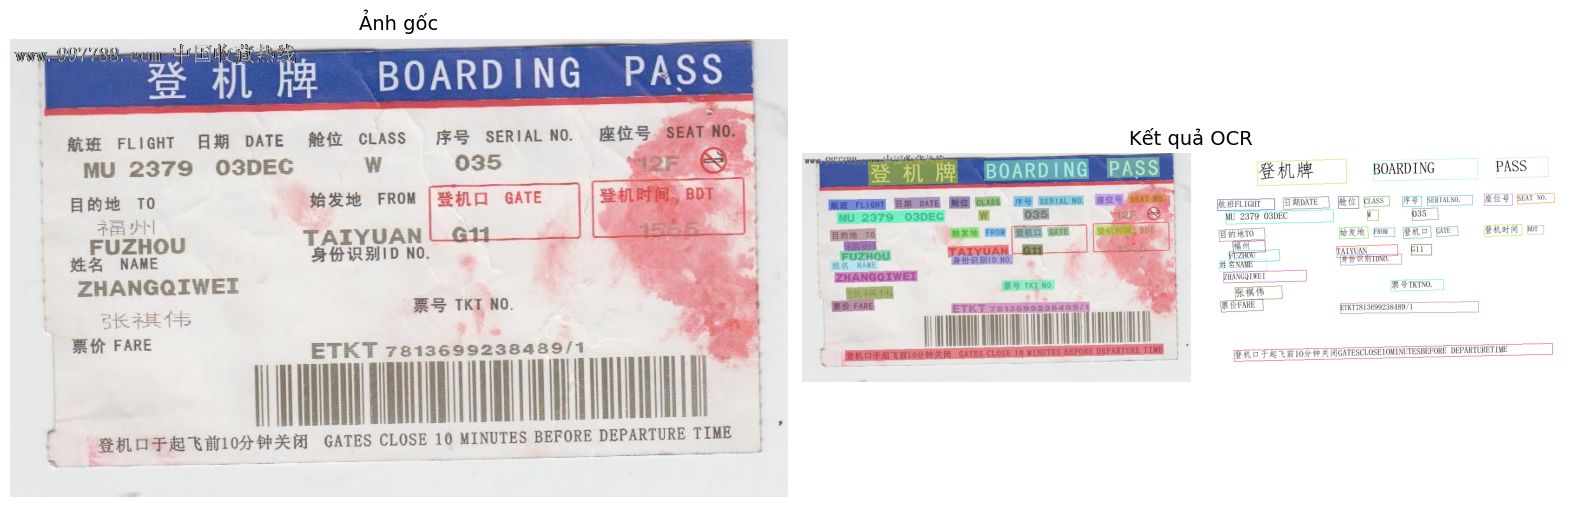

Đã lưu ảnh kết quả vào ocr_result_display.png


In [4]:
from paddleocr import PaddleOCR
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt
import os

# Download ảnh test
url = "https://paddle-model-ecology.bj.bcebos.com/paddlex/imgs/demo_image/general_ocr_002.png"
urllib.request.urlretrieve(url, "test_ocr.png")

# Chạy OCR
ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device='gpu'
)

result = ocr.predict("test_ocr.png")

# Lưu ảnh kết quả có vẽ bounding box
for res in result:
    res.save_to_img("output")  # lưu vào thư mục output/

# Hiển thị ảnh gốc và ảnh kết quả cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(Image.open("test_ocr.png"))
axes[0].set_title("Ảnh gốc", fontsize=14)
axes[0].axis("off")

# Tìm file output
output_file = [f for f in os.listdir("output") if f.endswith(".png") or f.endswith(".jpg")]
if output_file:
    axes[1].imshow(Image.open(f"output/{output_file[0]}"))
    axes[1].set_title("Kết quả OCR", fontsize=14)
    axes[1].axis("off")

plt.tight_layout()
plt.savefig("ocr_result_display.png", dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu ảnh kết quả vào ocr_result_display.png")

In [5]:
! pip install pymupdf reportlab tqdm

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.2 MB 1.4 MB/s eta 0:00:14
   -- ------------------------------------- 1.0/19.2 MB 1.5 MB/s eta 0:00:13
   -- ------------------------------------- 1.3/19.2 MB 1.6 MB/s eta 0:00:12
   --- ------------------------------------ 1.8/19.2 MB 1.7 MB/s eta 0:00:11
   ---- ----------------------------------- 2.4/19.2 MB 1.8 MB/s eta 0:00:10
   ------ --------------------------------- 3.1/19.2 MB 2.1 MB/s eta 0:00:08
   -------- ------------------------------- 3.9/19.2 MB 2.3 MB/s eta 0:00:07
   --------- ------------------------------ 4.7/19.2 MB 2.4 MB/s eta 0:00:06
   ----------- ---------------------------- 5.8/19.2 MB 2.7 MB/s eta 0:00:05
   -------------- ------------------------- 6.8/19.2 MB 2.9 MB/s eta 0:00:05
   ---------------- 